In [11]:
!pip install matplotlib pandas numpy seaborn 

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


In [4]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import os
import json
import re
import time


In [5]:
# Параметры и пути к данным
metricstext_dir = "../results_grok_pddl2pddl/metricstext"
plan_dirs = [f"../results_grok_pddl2pddl/finalset_full_{k}" for k in range(1, 6)]

# --- 1. Считывание метрик из metricstext ---
def parse_metricstext(runfilename):
    """Считывает метрики из фрагмента консоли из metricstext/runN"""
    agg_by_section = {}
    section = None
    current_type = None  # 'section' | 'subsection'
    subsection = None
    in_section_block = False
    in_subsection_block = False
    with open(runfilename, encoding="utf-8") as f:
        for line in f:
            m = re.match(r'\s{2}([a-z_]+):$', line)
            if "[sembenchrunning] Aggregate by section:" in line:
                current_type = 'section'
                in_section_block = True
                in_subsection_block = False
                continue
            if "[sembenchrunning] Aggregate by subsection:" in line:
                current_type = 'subsection'
                in_section_block = False
                in_subsection_block = True
                continue
            if in_section_block and m and current_type == 'section':
                section = m.group(1)
                agg_by_section[section] = {}
                continue
            if in_subsection_block and m and current_type == 'subsection':
                subsection = m.group(1)
                agg_by_section[subsection] = {}
                continue
            m2 = re.match(r'\s{4}(\w+): mean=([\d.]+) std=([\d.]+) n=(\d+) \[([\d.]+), ([\d.]+)\]', line)
            if m2 and (section or subsection):
                metric = m2.group(1)
                mean = float(m2.group(2))
                std = float(m2.group(3))
                n = int(m2.group(4))
                ci_low = float(m2.group(5))
                ci_high = float(m2.group(6))
                entry = dict(mean=mean, std=std, n=n, ci_low=ci_low, ci_high=ci_high)
                if in_section_block and section:
                    agg_by_section[section][metric] = entry
                elif in_subsection_block and subsection:
                    agg_by_section[subsection][metric] = entry
    return agg_by_section

In [6]:
# Сборка всех секционных метрик по всем запускам
section_metrics_all = []
subsection_metrics_all = []
for k in range(1, 6):
    metrics_section = parse_metricstext(os.path.join(metricstext_dir, f"run{k}"))
    # Первые восемь (или сколько есть) -- секции, остальные -- подсекции
    section_keys = [
        'agriculture','education','finance','games',
        'logistics','pharmaceutics','programming','tourism'
    ]
    sub_metrics = {key:value for key,value in metrics_section.items() if key not in section_keys}
    sec_metrics = {key:value for key,value in metrics_section.items() if key in section_keys}
    for section, md in sec_metrics.items():
        row = {"run": k, "section": section}
        for metric in md:
            row[metric + "_mean"] = md[metric]["mean"]
            row[metric + "_std"] = md[metric]["std"]
            row[metric + "_n"] = md[metric]["n"]
        section_metrics_all.append(row)
    for subsection, md in sub_metrics.items():
        row = {"run": k, "subsection": subsection}
        for metric in md:
            row[metric + "_mean"] = md[metric]["mean"]
            row[metric + "_std"] = md[metric]["std"]
            row[metric + "_n"] = md[metric]["n"]
        subsection_metrics_all.append(row)
section_metrics_df = pd.DataFrame(section_metrics_all)
subsection_metrics_df = pd.DataFrame(subsection_metrics_all)



In [7]:
# --- 2. Считывание длин сгенерированных планов ---

def extract_section_subsection_from_path(plan_path):
    # Пример пути: .../agriculture/crop_planning_and_field_operations/5/plan.pddl
    # Возвращает: ('agriculture', 'crop_planning_and_field_operations')
    parts = plan_path.replace("\\", "/").split("/")
    section = None
    subsection = None
    # Вариант 1: ищем совпадения с именами секций/подсекций
    section_choices = (
        set(section_metrics_df["section"].dropna().unique())
        if "section" in section_metrics_df.columns and not section_metrics_df.empty
        else set()
    )
    subsection_choices = (
        set(subsection_metrics_df["subsection"].dropna().unique())
        if "subsection" in subsection_metrics_df.columns and not subsection_metrics_df.empty
        else set()
    )
    for p in parts:
        if p in section_choices:
            section = p
        if p in subsection_choices:
            subsection = p
    # Вариант 2: угадываем "section/subsection/N", если section/subsection не определены выше
    if not section or not subsection:
        if len(parts) >= 4:
            section = parts[-4]
            subsection = parts[-3]
    return section, subsection

def plan_length(plan_path):
    # Подсчитываем количество действий (не считая комментарии, пустые и прочие строки)
    try:
        with open(plan_path, encoding='utf-8') as f:
            lines = f.readlines()
            actions = [l for l in lines if l.strip() and not l.startswith(';') and ('(' in l)]
        return len(actions)
    except Exception:
        return np.nan


def section_subsection_from_task_id(task_id):
    if not task_id or not isinstance(task_id, str):
        return None, None
    parts = task_id.split("__")
    if len(parts) < 2:
        return None, None
    return parts[0], parts[1]


def plan_length_from_text(plan_text):
    if not plan_text or not isinstance(plan_text, str):
        return np.nan
    actions = [
        l
        for l in plan_text.splitlines()
        if l.strip() and not l.strip().startswith(";") and "(" in l
    ]
    return len(actions)

In [8]:
plans_info = []
for k, run_dir in enumerate(plan_dirs, start=1):
    if not os.path.isdir(run_dir):
        continue
    for root, _, files in os.walk(run_dir):
        for file in files:
            if file.endswith(".pddl") and "plan" in file:
                plan_path = os.path.join(root, file)
                section, subsection = extract_section_subsection_from_path(plan_path)
                planlen = plan_length(plan_path)
                plans_info.append(
                    {
                        "run": k,
                        "plan_file": plan_path,
                        "length": planlen,
                        "section": section,
                        "subsection": subsection,
                    }
                )
            elif file.endswith(".json") and "__nl2pddl_debug" not in file:
                json_path = os.path.join(root, file)
                try:
                    with open(json_path, encoding="utf-8") as jf:
                        data = json.load(jf)
                except Exception:
                    continue
                task_id = data.get("id")
                section, subsection = section_subsection_from_task_id(task_id)
                plan_text = data.get("plan_pred_pddl")
                if plan_text is None and isinstance(data.get("openrouter_response"), dict):
                    try:
                        choices = data["openrouter_response"].get("choices") or []
                        if choices:
                            plan_text = (choices[0].get("message") or {}).get("content")
                    except Exception:
                        plan_text = None
                planlen = plan_length_from_text(plan_text)
                if not np.isnan(planlen):
                    plans_info.append(
                        {
                            "run": k,
                            "plan_file": json_path,
                            "length": planlen,
                            "section": section,
                            "subsection": subsection,
                        }
                    )

plans_df = pd.DataFrame(plans_info)



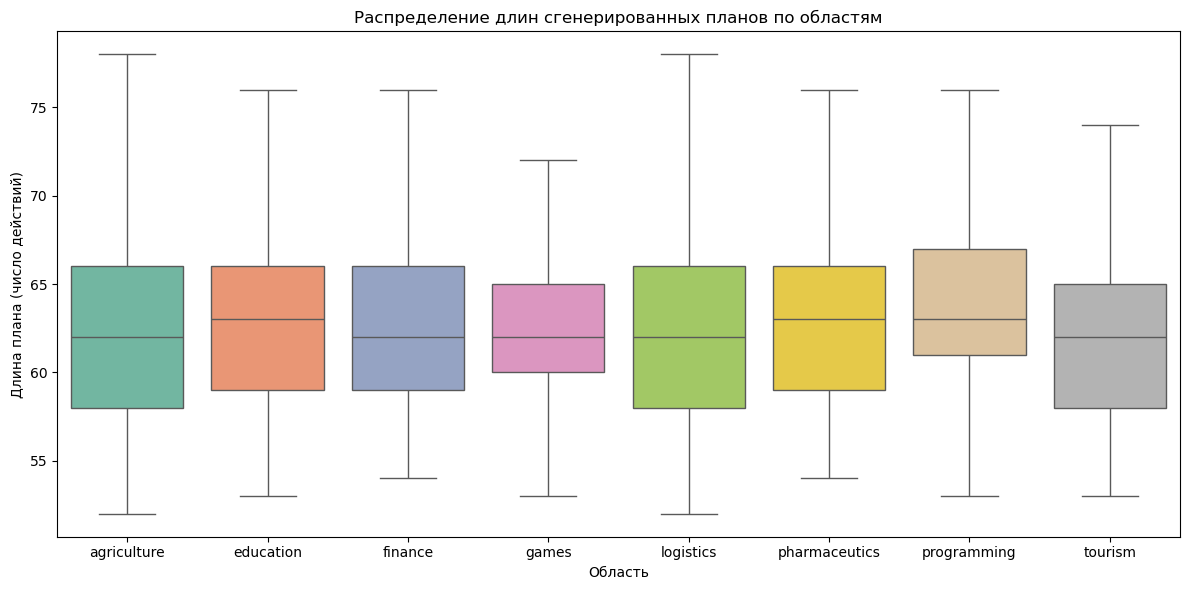

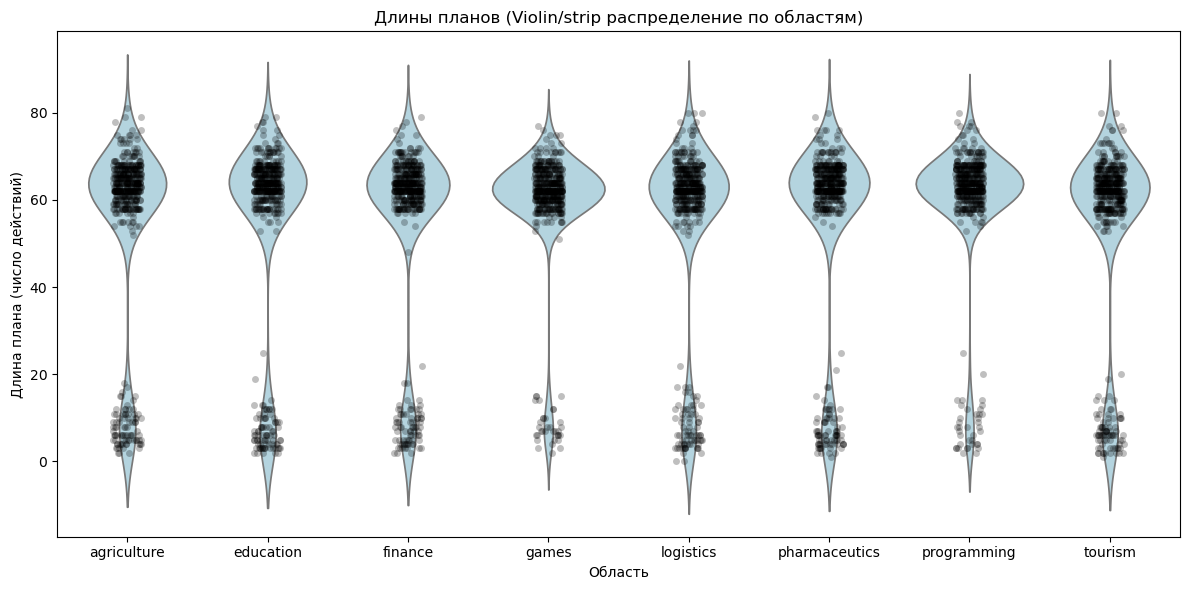

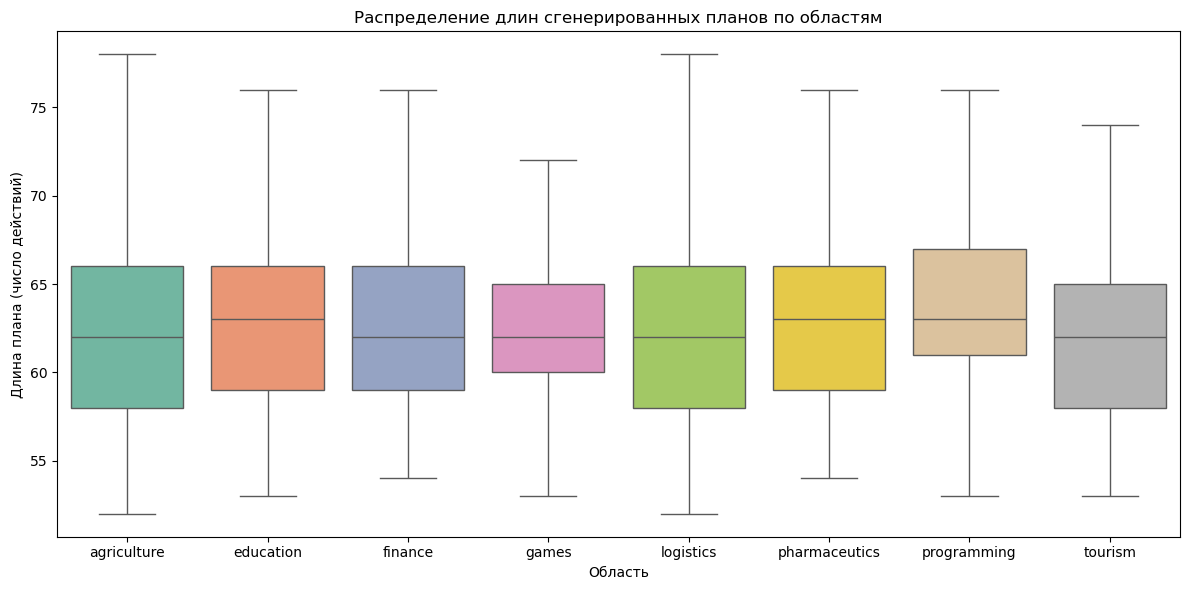

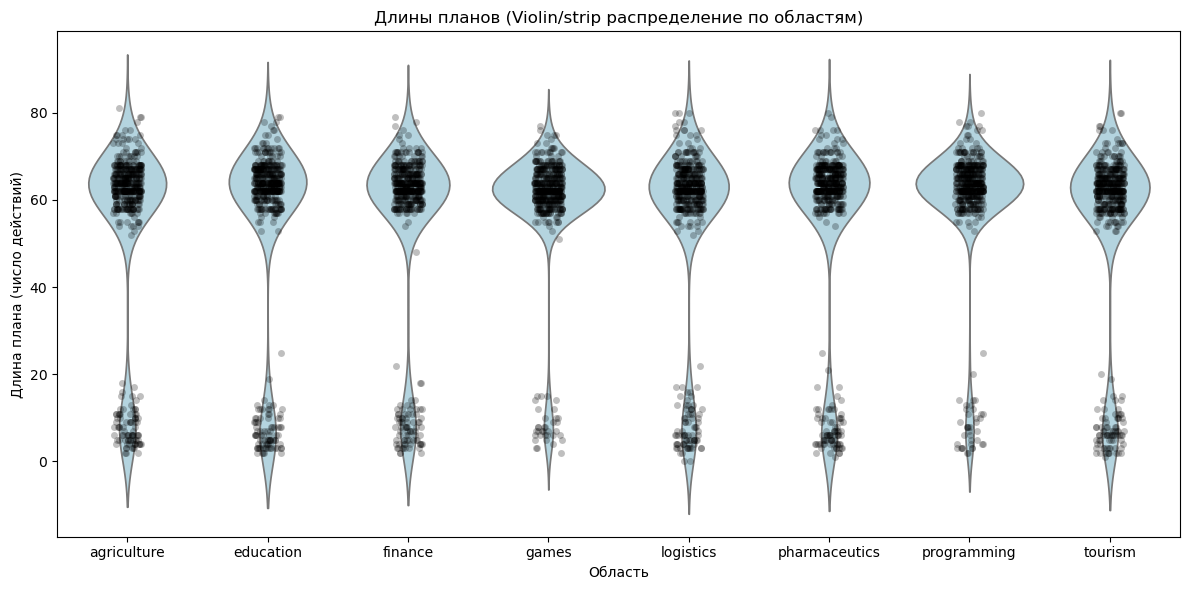

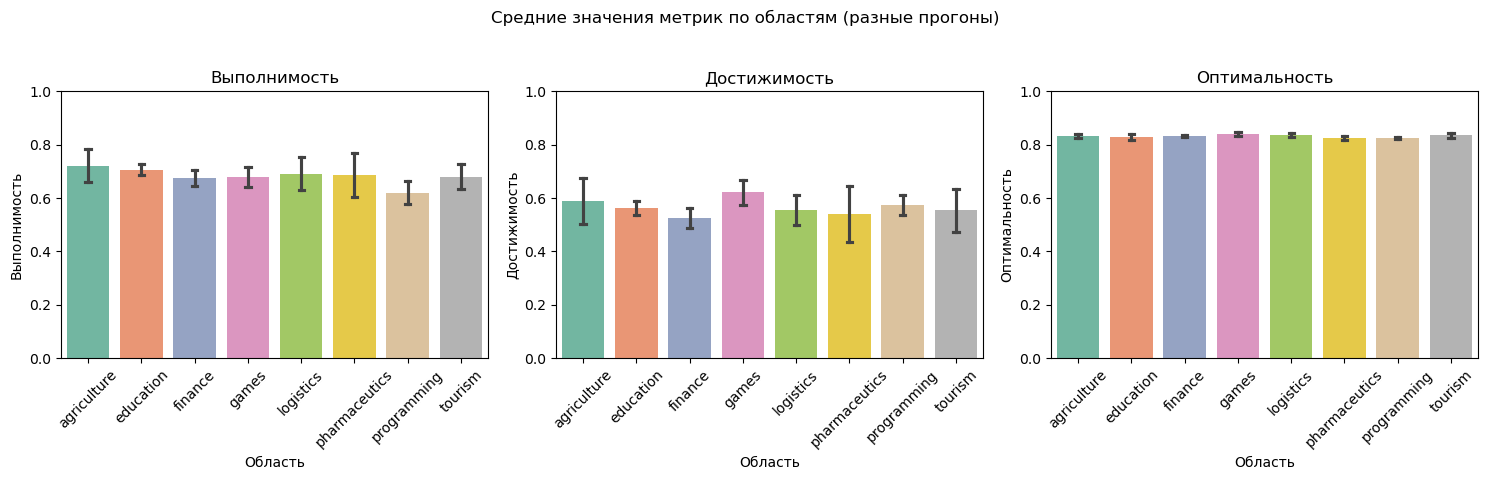

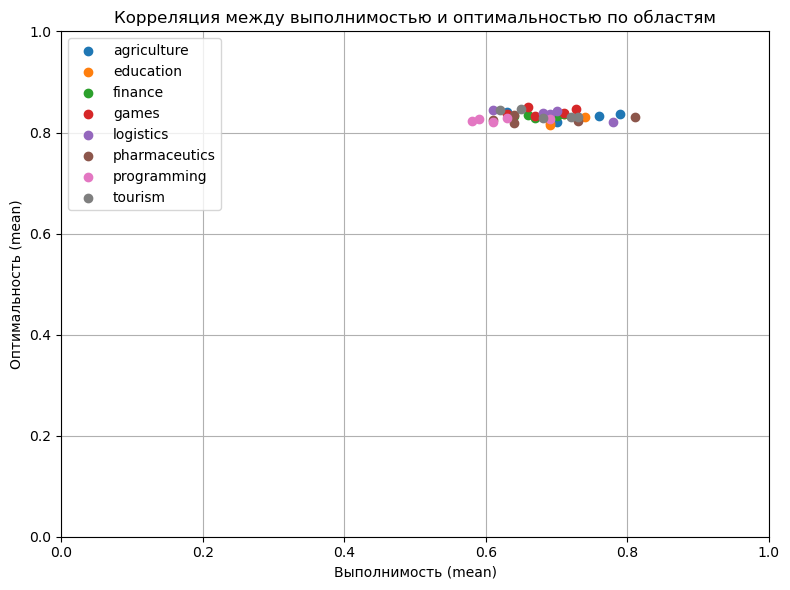

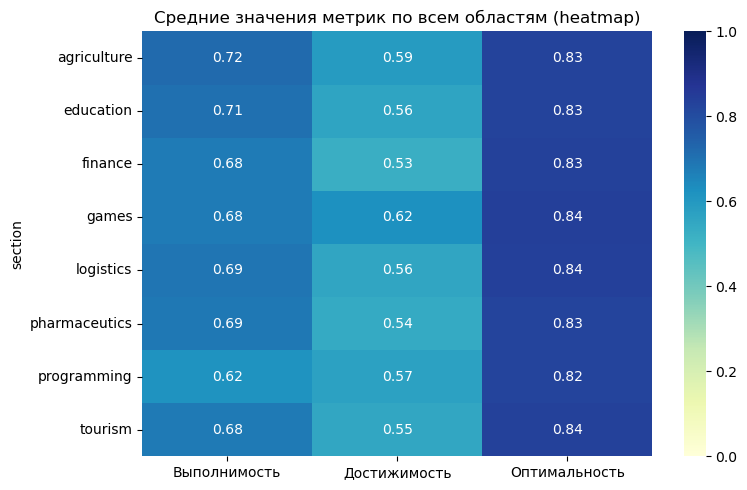

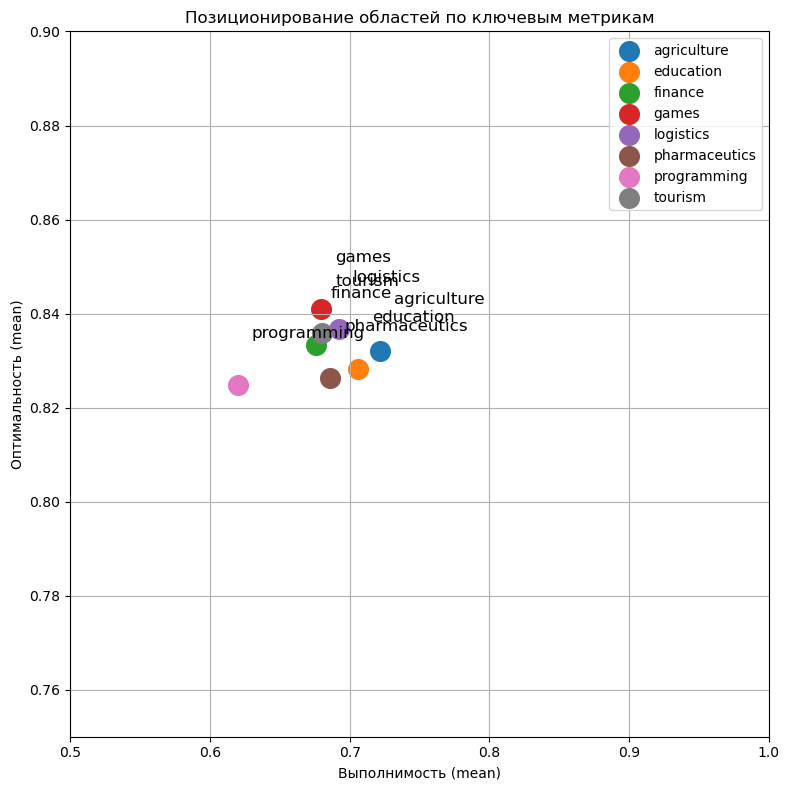

In [11]:
# Исправление проблемы: Иногда нет столбца "section", либо он весь NaN.
if plans_df.empty or "section" not in plans_df.columns or plans_df["section"].isnull().all():
    print("ВНИМАНИЕ: В plans_df отсутствует колонка 'section' или она пуста!")
else:
    # --- 3. Визуализация длин планов по секциям ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x="section",
        y="length",
        data=plans_df,
        hue="section",
        palette="Set2",
        legend=False,
        showfliers=False,
    )
    plt.title("Распределение длин сгенерированных планов по областям")
    plt.ylabel("Длина плана (число действий)")
    plt.xlabel("Область")
    plt.tight_layout()
    plt.show()

    # Более подробный violin + stripplot по секциям (где будет достаточно данных)
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="section", y="length", data=plans_df, inner=None, color="lightblue")
    sns.stripplot(x="section", y="length", data=plans_df, color="black", alpha=0.25)
    plt.title("Длины планов (Violin/strip распределение по областям)")
    plt.ylabel("Длина плана (число действий)")
    plt.xlabel("Область")
    plt.tight_layout()
    plt.show()

# --- 4. Визуализация метрик: Выполнимость, достижимость, оптимальность по секциям ---
metrics_to_plot = ['executability_mean', 'reachability_mean', 'optimality_ratio_mean']
metric_names = {'executability_mean': 'Выполнимость', 'reachability_mean': 'Достижимость', 'optimality_ratio_mean': 'Оптимальность'}

if not section_metrics_df.empty:
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(metrics_to_plot, 1):
        plt.subplot(1, 3, i)
        if metric in section_metrics_df.columns:
            sns.barplot(
                x="section",
                y=metric,
                data=section_metrics_df,
                hue="section",
                palette="Set2",
                legend=False,
                errorbar="sd",
                capsize=0.1,
            )
            plt.ylim(0, 1)
            plt.ylabel(metric_names[metric])
            plt.xlabel("Область")
            plt.title(metric_names[metric])
            plt.xticks(rotation=45)
    plt.suptitle("Средние значения метрик по областям (разные прогоны)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 5. Корреляция между метриками: Выполнимость vs Оптимальность per section ---
    plt.figure(figsize=(8, 6))
    for s in section_metrics_df['section'].unique():
        df = section_metrics_df[section_metrics_df['section']==s]
        plt.scatter(df['executability_mean'], df['optimality_ratio_mean'], label=s)
    plt.xlabel("Выполнимость (mean)")
    plt.ylabel("Оптимальность (mean)")
    plt.title("Корреляция между выполнимостью и оптимальностью по областям")
    plt.legend()
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- 6. Тёпловая карта всех метрик по всем областям ---
    heat_df = section_metrics_df.groupby('section')[metrics_to_plot].mean()
    heat_df = heat_df.rename(columns=metric_names)
    plt.figure(figsize=(8, 5))  
    sns.heatmap(heat_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Средние значения метрик по всем областям (heatmap)")
    plt.tight_layout()
    plt.show()

    # --- 7. Диаграмма рассеяния для наглядного сравнения областей (метрики выполнимости и оптимальности) ---
    plt.figure(figsize=(8, 8))
    for s in heat_df.index:
        x = heat_df.loc[s, metric_names["executability_mean"]]
        y = heat_df.loc[s, metric_names["optimality_ratio_mean"]]
        plt.scatter(x, y, s=200, label=s)
        plt.text(x+0.01, y+0.01, s, fontsize=12)
    plt.xlabel("Выполнимость (mean)")
    plt.ylabel("Оптимальность (mean)")
    plt.title("Позиционирование областей по ключевым метрикам")
    plt.xlim(0.5, 1)
    plt.ylim(0.75, 0.90)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()
else:
    print("ВНИМАНИЕ: section_metrics_df пуст!")






In [ ]:
# --- 3c. Сырые распределения длин планов по каждой области без приближений ---
if plans_df.empty or "section" not in plans_df.columns or plans_df["section"].isnull().all():
    print("ВНИМАНИЕ: В plans_df отсутствует колонка 'section' или она пуста!")
else:
    section_order = sorted(plans_df["section"].dropna().unique())
    n_sections = len(section_order)
    n_cols = 1
    n_rows = n_sections

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.6 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, section in zip(axes_flat, section_order):
        section_lengths = plans_df.loc[plans_df["section"] == section, "length"].dropna()
        unique_lengths = np.sort(section_lengths.unique())
        if len(unique_lengths) == 0:
            ax.set_visible(False)
            continue

        bins = np.arange(unique_lengths.min() - 0.5, unique_lengths.max() + 1.5, 1)
        ax.hist(section_lengths, bins=bins, color="steelblue", edgecolor="black")
        tick_step = max(1, int(np.ceil(len(unique_lengths) / 18)))
        ax.set_xticks(unique_lengths[::tick_step])
        ax.set_title(section)
        ax.set_xlabel("Длина плана (число действий)")
        ax.set_ylabel("Частота")
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", labelrotation=0)

    for ax in axes_flat[n_sections:]:
        ax.set_visible(False)

    fig.suptitle("Распределения длин планов по областям без приближений", fontsize=14)
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()


In [ ]:
# --- 3d. Отдельные errorbar-графики по метрикам с сортировкой областей по убыванию ---
metrics_to_plot = ["executability_mean", "reachability_mean", "optimality_ratio_mean"]
metric_names = {
    "executability_mean": "Выполнимость",
    "reachability_mean": "Достижимость",
    "optimality_ratio_mean": "Оптимальность",
}
metric_colors = {
    "executability_mean": "tab:blue",
    "reachability_mean": "tab:orange",
    "optimality_ratio_mean": "tab:green",
}

if section_metrics_df.empty:
    print("ВНИМАНИЕ: section_metrics_df пуст!")
else:
    for metric in metrics_to_plot:
        stats = (
            section_metrics_df.groupby("section")[metric]
            .agg(["mean", "std"])
            .sort_values("mean", ascending=False)
        )
        stats = stats.dropna(subset=["mean"])
        x = np.arange(len(stats))
        y = stats["mean"].to_numpy()
        yerr = stats["std"].fillna(0).to_numpy()
        y_min = max(0, np.min(y - yerr) - 0.03)
        y_max = min(1, np.max(y + yerr) + 0.03)
        if y_max - y_min < 0.08:
            center = (y_min + y_max) / 2
            y_min = max(0, center - 0.04)
            y_max = min(1, center + 0.04)

        plt.figure(figsize=(14, 5))
        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            capsize=5,
            elinewidth=2,
            markersize=7,
            color=metric_colors[metric],
        )
        plt.title(f"{metric_names[metric]} по областям")
        plt.xlabel("Область")
        plt.ylabel("Среднее значение")
        plt.xticks(x, stats.index, rotation=0)
        plt.ylim(y_min, y_max)
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
